# Normal Distribution

We already met the normal distribution formula earlier, when we were trying to understand how a density function works mechanically. This notebook goes deeper, covering what the normal distribution actually represents, why it shows up everywhere, and its key properties.

## What is Normal Distribution?

Normal distribution, also called Gaussian distribution, is a continuous probability distribution that is symmetrical around the mean, forming a bell shaped curve.

A few defining features of this curve:

* **Tail:** the curve has two tails, one on each side, that stretch out toward infinity.
* **Asymptotic in nature:** the tails get closer and closer to zero but never actually touch it. No matter how far out you go, there's technically always a tiny bit of density left.
* **Lots of points near the mean, very few far away:** most of the data clusters close to the center, and it becomes rarer and rarer the further you move away from the mean in either direction.

The whole shape is controlled by just two parameters:

* **Mean (μ):** decides where the center of the curve sits.
* **Standard deviation (σ):** decides how wide or narrow the curve is.

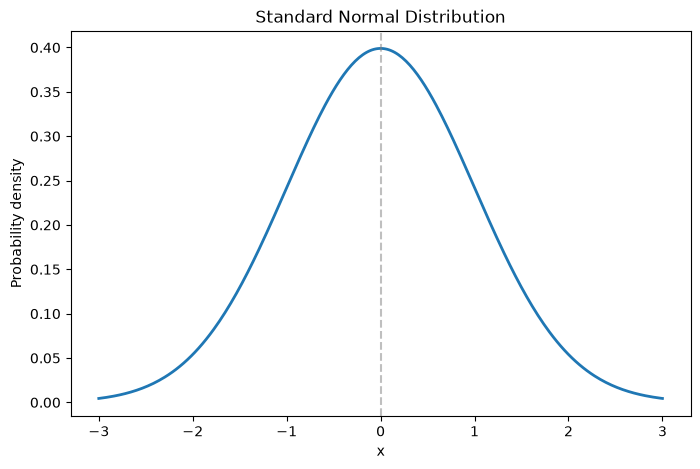

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-3, 3, 300)
y = norm.pdf(x, loc=0, scale=1)

plt.figure(figsize=(8, 5))
plt.plot(x, y, color='#1f77b4', linewidth=2)
plt.title('Standard Normal Distribution')
plt.xlabel('x')
plt.ylabel('Probability density')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

## Why Is It So Important?

Normal distribution shows up constantly in nature and real data. Heights of people, weights of objects, IQ scores, measurement errors, a huge number of natural and human-made processes tend to follow this exact bell shape.

Because of this, normal distribution gives us a reliable, well understood way to model and analyze many kinds of real world data, without needing a different custom approach for every single case.

Here's the formula again, the one we already broke down mechanically earlier:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

This looks slightly different from how we wrote it before, but it's the exact same formula, just rearranged. Instead of writing $\frac{(x-\mu)^2}{2\sigma^2}$ directly, it factors out a $\frac{1}{2}$ and squares the standardized distance $\frac{x-\mu}{\sigma}$. Both forms give identical results.

## Standard Normal Variate (Z)

A Standard Normal Variate, usually called Z, is just a standardized version of the normal distribution. It always has mean = 0 and standard deviation = 1, no matter what the original data looked like.

If X follows a normal distribution with mean μ and standard deviation σ, we write this as:

$$X \sim N(\mu, \sigma)$$

Standardizing X turns it into Z, which follows:

$$Z \sim N(0, 1)$$

Standardizing a normal distribution lets us compare completely different distributions on the same scale, and lets us calculate probabilities using standard tables or software, instead of needing separate tables for every possible μ and σ combination.

## The Standardizing Formula

The general normal distribution formula is:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

If we substitute $z = \frac{x-\mu}{\sigma}$ and set $\mu = 0$, $\sigma = 1$, this simplifies to the standard normal form:

$$f(z) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}z^2}$$

This is the exact same bell curve shape, just rescaled so it's always centered at 0 with a spread of 1. The term $z = \frac{x - \mu}{\sigma}$ is called the **z-score**, and it tells us how many standard deviations away from the mean a value sits.

## A Concrete Example: Age

Say we have a small dataset of ages: 27, 28, 61, 73. Let's say this data has some mean (μ) and standard deviation (σ), calculated from the whole group.

To find out how unusual an age of 27 is compared to the rest of the group, we convert it into a z-score:

$$z = \frac{27 - \mu}{\sigma}$$

This answers the question: "how many standard deviations below or above the average is 27?" A z-score close to 0 means the value is close to average. A large positive or negative z-score means the value is unusually far from average, in one direction or the other.

Let's calculate this with real numbers in code.

In [6]:
import numpy as np

ages = np.array([27, 28, 61, 73])

mu = ages.mean()
sigma = ages.std()

z_scores = (ages - mu) / sigma

for age, z in zip(ages, z_scores):
    print(f"Age {age}: z-score = {z:.2f}")

Age 27: z-score = -1.00
Age 28: z-score = -0.95
Age 61: z-score = 0.68
Age 73: z-score = 1.27


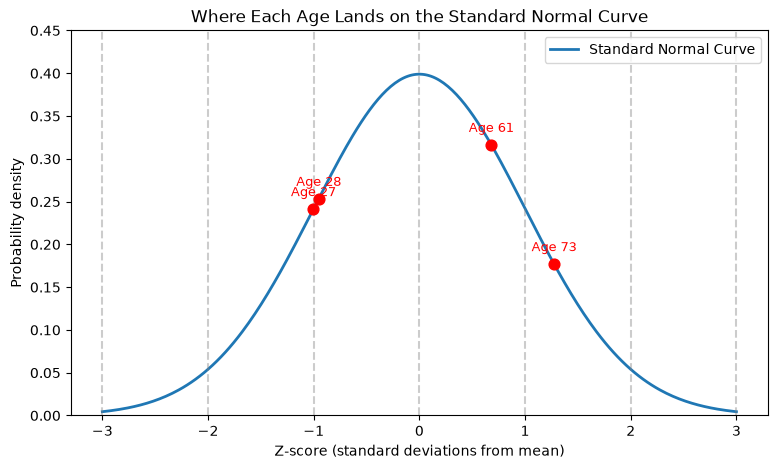

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# the standard normal curve itself
z_range = np.linspace(-3, 3, 300)
y_range = norm.pdf(z_range, loc=0, scale=1)

plt.figure(figsize=(9, 5))
plt.plot(z_range, y_range, color='#1f77b4', linewidth=2, label='Standard Normal Curve')

# grey lines marking each standard deviation step
for sd in [-3, -2, -1, 0, 1, 2, 3]:
    plt.axvline(sd, color='gray', linestyle='--', alpha=0.4)

# plot each age as a dot sitting on the curve at its own z-score
for age, z in zip(ages, z_scores):
    density_at_z = norm.pdf(z, loc=0, scale=1)
    plt.scatter(z, density_at_z, color='red', zorder=5, s=60)
    plt.text(z, density_at_z + 0.015, f"Age {age}", ha='center', fontsize=9, color='red')

plt.title('Where Each Age Lands on the Standard Normal Curve')
plt.xlabel('Z-score (standard deviations from mean)')
plt.ylabel('Probability density')
plt.ylim(0, 0.45)
plt.legend()
plt.show()

## Reading the Z-Scores

Looking at our results:

* **27 and 28** have negative z-scores, meaning they sit below the average age in this group.
* **61 and 73** have positive z-scores, sitting above the average.
* **73 has the largest z-score (1.27)**, meaning it's the value that sits furthest from the mean, relatively speaking.

This is the whole point of standardizing. Without z-scores, you'd only know the raw ages, 27, 28, 61, 73, but you wouldn't immediately know which ones are "normal" for this group and which stand out. The z-score instantly tells us how far each value sits from the average, measured in standard deviations, a scale that works the same way regardless of what the original units were (age, height, bill amount, anything).

This is also exactly why we can use one single standard normal table or function to calculate probabilities for any normally distributed dataset. Once converted to z-scores, every dataset speaks the same standardized language.

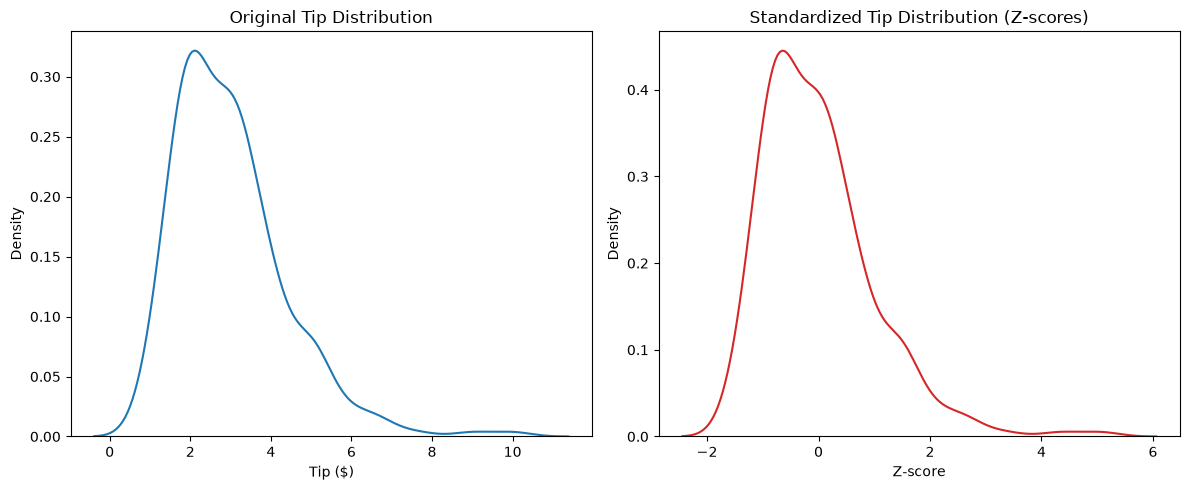

In [16]:
# lets apply the standadizing technique on real data 

import seaborn as sns
import matplotlib.pyplot as plt

data = sns.load_dataset('tips')

# standardize the tip column
tip_mean = data['tip'].mean()
tip_std = data['tip'].std()
data['tip_standardized'] = (data['tip'] - tip_mean) / tip_std

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(data['tip'], ax=axes[0], color='#1f77b4')
axes[0].set_title('Original Tip Distribution')
axes[0].set_xlabel('Tip ($)')
axes[0].set_ylabel('Density')

sns.kdeplot(data['tip_standardized'], ax=axes[1], color='#d62728')
axes[1].set_title('Standardized Tip Distribution (Z-scores)')
axes[1].set_xlabel('Z-score')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

## Comparing Original vs Standardized Tip Distribution

Both curves have the exact same shape, same peak, same right skew, same tail. Only the x-axis changed, dollars on the left, z-scores (standard deviations from the mean) on the right.

## Why Do We Even Need Standardization?

Here's a practical reason. Suppose adult male heights in a population follow a normal distribution with mean 68 inches and standard deviation 3 inches:

$$X \sim N(68, 3)$$

**Question:** what's the probability that a randomly picked adult male is taller than 72 inches?

Instead of working directly with 68 and 72 (raw inches), we convert 72 into a z-score first:

$$z = \frac{72 - 68}{3} = \frac{4}{3} \approx 1.33$$

This tells us 72 inches is 1.33 standard deviations above the mean, no matter what the original units were.

## What Are Z-Tables?

A z-table tells you the area under the standard normal curve to the **left** of a given z-score, in other words, the probability that a value is less than that z-score.

This is the real reason standardization matters. Nobody needs to calculate a fresh table of probabilities for every possible mean and standard deviation combination. Once any value is converted to a z-score, we can look up its probability from one single, universal table, the same table works whether the original data was height, age, or tip amount.

For z = 1.33, the table gives us the area to the left, approximately 0.9082. Since we want the probability of being **taller** than 72 inches (to the right), we subtract from 1:

$$P(X > 72) = 1 - 0.9082 = 0.0918$$

So about 9.18% of adult males in this population are taller than 72 inches.

In [17]:
from scipy.stats import norm

mu = 68
sigma = 3
x = 72

z = (x - mu) / sigma
print(f"Z-score: {z:.2f}")

prob_less_than = norm.cdf(z)
prob_greater_than = 1 - prob_less_than

print(f"P(X < 72) = {prob_less_than:.4f}")
print(f"P(X > 72) = {prob_greater_than:.4f}")

Z-score: 1.33
P(X < 72) = 0.9088
P(X > 72) = 0.0912


## Reading the Z-Table

Here's an actual z-table. To find the probability for z = 1.33, we split it into two parts: the whole number plus first decimal (1.3), and the second decimal (0.03).

![Z-table showing standard normal probabilities](./assets/normal-distribution/z-table.png)

To read this table for z = 1.33:

1. Find the row labeled **1.3** on the left side.
2. Find the column labeled **.03** along the top.
3. The value where that row and column meet is the answer.

Looking at row 1.3 and column .03, we get **0.9082**. This means the area under the curve to the left of z = 1.33 is 0.9082, or in plain terms, about 90.82% of all values fall below z = 1.33.

This is exactly where our earlier number came from. We didn't need to integrate the normal distribution formula by hand, the table already has these areas pre-calculated for every combination of z-score, down to two decimal places. This is the whole point of standardizing first, every z-score maps to the exact same universal table, no matter what the original data's mean and standard deviation were.

## The Empirical Rule (68-95-99.7 Rule)

![Empirical Rule](./assets/empiricalRule/er.png)

Normal distribution has a well known pattern called the empirical rule, or the 68-95-99.7 rule. It tells us roughly how much of the data falls within each standard deviation band around the mean:

* About **68%** of the data falls within 1 standard deviation of the mean.
* About **95%** of the data falls within 2 standard deviations of the mean.
* About **99.7%** of the data falls within 3 standard deviations of the mean.

This gives a quick, practical way to judge how typical or unusual a value is, without doing any lookup or calculation. If a value sits within 1 standard deviation of the mean, it's common. If it's past 3 standard deviations, it's extremely rare.

## The Area Under the Curve

We now have three different ways to connect a point on this curve to an actual probability:

1. **PDF (height of the curve):** tells us density at one point, how crowded values are there, not a direct probability.
2. **Z-table:** gives us the area to the left of any specific z-score, a quick lookup.
3. **Empirical rule:** gives us quick, memorized percentages for whole standard deviation bands (1, 2, or 3 SD), without needing a table at all.

All three are really expressing the same underlying idea, area under the curve equals probability, just at different levels of precision. The empirical rule is the fastest, roughest estimate. The z-table gives an exact number for any specific z-score. And the full PDF integral (which scipy's `norm.cdf` calculates for us) gives the most precise, exact answer of all.

## Skewness

Skewness measures how asymmetric a distribution is, in other words, how much it deviates from the perfectly symmetric normal curve.

In a perfectly symmetric distribution, the mean, median, and mode all sit at the exact same point. In a skewed distribution, these three values pull apart from each other, and the curve ends up with a longer tail stretching out on one side.

Skewness comes in three flavors:

* **Positive skew:** the tail stretches out to the right. Mode is smallest, then median, then mean is largest, since a few unusually high values pull the mean upward.
* **Symmetrical (zero skew):** mean, median, and mode all line up at the same point, like our earlier normal distribution examples.
* **Negative skew:** the tail stretches out to the left. Mean is smallest, then median, then mode is largest, since a few unusually low values pull the mean downward.

The bigger the skew, the farther apart mode, median, and mean drift from each other.

In [25]:
tips = sns.load_dataset('tips')

mean_val = tips['total_bill'].mean()
median_val = tips['total_bill'].median()
mode_val = tips['total_bill'].mode()[0]

print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Mode: {mode_val:.2f}")
print(f"skewness: {tips['total_bill'].skew()}")

Mean: 19.79
Median: 17.80
Mode: 13.42
skewness: 1.1332130376158205


<Axes: xlabel='total_bill', ylabel='Density'>

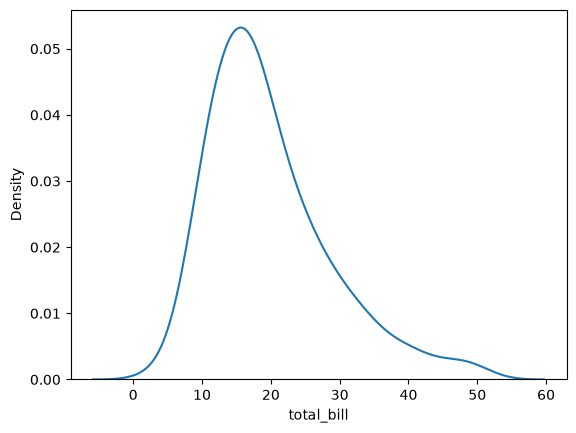

In [26]:
sns.kdeplot(tips['total_bill'])


## Confirming the Skew in Real Data

This confirms exactly what we expected. For `total_bill`:

* **Mean (19.79)** is the largest.
* **Median (17.80)** sits in the middle.
* **Mode (13.42)** is the smallest.

This ordering, mean > median > mode, is the signature of a **positive skew**. The calculated skewness value, 1.13, confirms this numerically, a positive number means the tail stretches to the right.

The KDE plot shows this visually too, a sharp peak around 13 to 15, then a long gentle tail trailing off toward 50 and 60. A few unusually large bills pull the mean upward, away from where most of the actual data sits, which is exactly why mean ended up being the largest of the three.

This also explains why our earlier attempt to fit a normal distribution onto `total_bill` didn't match perfectly, a true normal distribution always has zero skew, with mean, median, and mode all equal. Since real bill data is skewed, forcing a symmetric bell curve onto it was always going to be an approximation, not a perfect fit.

## Kurtosis

Kurtosis is the 4th statistical moment. It's a measure of the **tailedness** of a probability distribution, in plain words, it tells us how heavy or light the tails of a distribution are compared to a normal distribution.

Like skewness, kurtosis describes a particular shape characteristic of a distribution. But while skewness is about asymmetry (does the curve lean left or right), kurtosis is about how extreme the tails are, in other words, how likely we are to see unusually large or small outlier values.

## Types of Kurtosis

Based on tail heaviness, distributions fall into three categories:

* **Mesokurtic:** tails behave like a normal distribution. This is the baseline, kurtosis around 3 (or 0, if using "excess kurtosis," which subtracts 3 from the raw value).
* **Leptokurtic:** heavier tails and a sharper, taller peak than normal. More of the data sits far from the mean than a normal distribution would predict, meaning extreme values (outliers) are more common.
* **Platykurtic:** lighter tails and a flatter peak than normal. Data is more tightly packed near the mean, with fewer extreme outliers than a normal distribution would predict.

In short, kurtosis tells us how likely we are to encounter extreme values. A high kurtosis warns that outliers are more common than a normal distribution would suggest, which matters a lot in fields like finance, where underestimating extreme risk can be costly.

In [27]:
from scipy.stats import kurtosis

excess_kurtosis = kurtosis(tips['total_bill'])
print(f"Excess kurtosis of total_bill: {excess_kurtosis:.4f}")

Excess kurtosis of total_bill: 1.1692


## Interpreting the Kurtosis Result

`total_bill` has an excess kurtosis of **1.17**, a positive value, meaning it's **leptokurtic**.

This means `total_bill` has heavier tails than a normal distribution, unusually large bills happen more often than a bell curve would predict. These are the same outliers we spotted earlier in the box plot.

So `total_bill` is both skewed and leptokurtic, two signs pointing to the same thing, real spending data doesn't follow a clean symmetric curve the way a true normal distribution would.